# Import Library


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

import re
import math
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


nltk.download('wordnet')
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset1 : data_52_topic.csv

## Load Data

In [80]:
file_path = '/content/drive/MyDrive/GNG5125_Term Project/data_52_topic.csv'
df1 = pd.read_csv(file_path)
df1.head()

,topic,text
0,Acne,Acne Definition Acne is a common skin conditio...
1,Alzheimer's disease,Alzheimer's disease Definition Alzheimer's dis...
2,Anxiety,Anxiety Definition Anxiety is a multisystem re...
3,Anxiety disorders,Anxiety disorders Definition Anxiety disorders...
4,Asthma,Asthma Definition Asthma comprises a group of ...


## Clean Data

In [81]:
def clean_data(text):
    # แปลงข้อความทั้งหมดเป็นตัวพิมพ์เล็ก
    text = text.lower()

    # Remove all characters except A-Z, a-z, 0-9, and '-'
    cleaned_text = re.sub(r'[^a-z-]', ' ', text)

    # Load English stopwords
    stop_words = set(stopwords.words("english"))

    # Split text into words
    words = cleaned_text.split()

    # Remove stopwords
    cleaned_words = [word for word in words if word.lower() not in stop_words]
    cleaned_text = " ".join(cleaned_words)

    # Remove single character words (ตัวอักษรที่อยู่ตัวเดียว)
    cleaned_text = re.sub(r'\b[a-zA-Z0-9]\b', '', cleaned_text)

    return cleaned_text

In [82]:
df1.loc[:, 'cleaned_text'] = df1['text'].apply(clean_data)

In [83]:
df1.head()

,topic,text,cleaned_text
0,Acne,Acne Definition Acne is a common skin conditio...,acne definition acne common skin condition cha...
1,Alzheimer's disease,Alzheimer's disease Definition Alzheimer's dis...,alzheimer disease definition alzheimer disease...
2,Anxiety,Anxiety Definition Anxiety is a multisystem re...,anxiety definition anxiety multisystem respons...
3,Anxiety disorders,Anxiety disorders Definition Anxiety disorders...,anxiety disorders definition anxiety disorders...
4,Asthma,Asthma Definition Asthma comprises a group of ...,asthma definition asthma comprises group recur...


# Split Data

In [84]:
# Count the number of words in the 'col' column
df1.loc[:, 'word_count'] = df1['text'].apply(lambda x: len(str(x).split()))

# Calculate min, max, and average word count
min_word_count = df1['word_count'].min()
max_word_count = df1['word_count'].max()
avg_word_count = df1['word_count'].mean()

# Display the results
print(f"Min word count: {min_word_count}")
print(f"Max word count: {max_word_count}")
print(f"Avg word count: {avg_word_count}")

Min word count: 421
Max word count: 9564
Avg word count: 2568.061224489796


In [85]:


# Create an empty list to store the split data for df2
split_data = []

# Iterate through each row in df1
for index, row in df1.iterrows():
    # Get the cleaned_text and topic from df1
    cleaned_text = row['cleaned_text']
    topic = row['topic']

    # Split the cleaned_text into words
    words = cleaned_text.split()

    # Calculate the total number of words
    word_count = len(words)

    # Calculate the number of rows to split based on word count (using 400-500 words per row as base)
    num_rows = word_count // 500  # Calculate how many full 500-word rows we can have

    # If there's a remainder when dividing by 500, we need one more row
    if word_count % 500 != 0:
        num_rows += 1

    # Calculate the number of words per row (the rest of the rows will have 500 words, but the last one will be smaller)
    words_per_row = word_count // num_rows

    # Adjust for the min 400 words per row (make sure that no row has fewer than 400 words)
    if words_per_row < 400:
        words_per_row = 400

    start = 0
    for _ in range(num_rows):
        end = start + words_per_row
        chunk = ' '.join(words[start:end])
        split_data.append({'topic': topic, 'cleaned_text': chunk})
        start = end

    # If there are remaining words that don't fit into the calculated row size, add them as a final chunk
    if start < word_count:
        chunk = ' '.join(words[start:])
        split_data.append({'topic': topic, 'cleaned_text': chunk})

df2 = pd.DataFrame(split_data)
df2.head()

,topic,cleaned_text
0,Acne,acne definition acne common skin condition cha...
1,Acne,oral key terms androgens male sex hormones lin...
2,Acne,dead skin cells help unclog pores kill bacteri...
3,Acne,attention paid topregnancy tests contraceptive...
4,Acne,treatment


In [86]:
df2.shape[0]

198

In [87]:
# Count the number of words in the 'col' column
df2.loc[:, 'word_count'] = df2['cleaned_text'].apply(lambda x: len(str(x).split()))
df3 = df2[df2['word_count'] >= 300]
df3.shape[0]

170

In [88]:
# Count the number of words in the 'col' column
df3.loc[:, 'word_count'] = df3['cleaned_text'].apply(lambda x: len(str(x).split()))

# Calculate min, max, and average word count
min_word_count = df3['word_count'].min()
max_word_count = df3['word_count'].max()
avg_word_count = df3['word_count'].mean()

# Display the results
print(f"Min word count: {min_word_count}")
print(f"Max word count: {max_word_count}")
print(f"Avg word count: {avg_word_count}")

Min word count: 337
Max word count: 496
Avg word count: 440.2529411764706


In [89]:
df3 = df3[["topic", "cleaned_text"]]
df3.head()

,topic,cleaned_text
0,Acne,acne definition acne common skin condition cha...
1,Acne,oral key terms androgens male sex hormones lin...
2,Acne,dead skin cells help unclog pores kill bacteri...
3,Acne,attention paid topregnancy tests contraceptive...
5,Alzheimer's disease,alzheimer disease definition alzheimer disease...


In [90]:
# Initializing stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [91]:
def apply_lemmatization(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

df3.loc[:, 'lemmatization'] = df3['cleaned_text'].apply(apply_lemmatization)

In [92]:
def apply_stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df3['stemming'] = df3['cleaned_text'].apply(apply_stemming)

In [93]:
df3.head()

,topic,cleaned_text,lemmatization,stemming
0,Acne,acne definition acne common skin condition cha...,acne definition acne common skin condition cha...,acn definit acn common skin condit character p...
1,Acne,oral key terms androgens male sex hormones lin...,oral key term androgen male sex hormone linked...,oral key term androgen male sex hormon link de...
2,Acne,dead skin cells help unclog pores kill bacteri...,dead skin cell help unclog pore kill bacteria ...,dead skin cell help unclog pore kill bacteria ...
3,Acne,attention paid topregnancy tests contraceptive...,attention paid topregnancy test contraceptive ...,attent paid topregn test contracept requir wom...
5,Alzheimer's disease,alzheimer disease definition alzheimer disease...,alzheimer disease definition alzheimer disease...,alzheim diseas definit alzheim diseas ad commo...


In [94]:
# output_path = "/content/drive/MyDrive/cleaned_data_20250327_2311.csv"
# df3.to_csv(output_path, index=False)

# Kmean

In [95]:
# find the best num_clusters
def get_cluster_info(min_cluster, max_cluster, df3, X):
    num_clusters_list = []  # list to store num_clusters
    topics_in_multiple_groups_list = []  # list to store length of topics_in_multiple_groups

    # Loop over the range of num_clusters
    for num_clusters in range(min_cluster, max_cluster + 1):
        # Use MiniBatchKMeans for clustering
        kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=0, batch_size=100)
        df3["cluster"] = kmeans.fit_predict(X)

        # Find unique mapping between 'cluster' and 'topic'
        mapping = df3.groupby('cluster')['topic'].unique().reset_index()

        # Find the duplicate topics across different clusters
        duplicate_topics = df3.groupby('topic')['cluster'].nunique()

        # Filter topics that appear in more than one cluster
        topics_in_multiple_groups = duplicate_topics[duplicate_topics > 1]

        # Append the results to the lists
        num_clusters_list.append(num_clusters)
        topics_in_multiple_groups_list.append(len(topics_in_multiple_groups))

    return num_clusters_list, topics_in_multiple_groups_list

## Use lemmatization

In [96]:
# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=2)
X = vectorizer.fit_transform(df3["lemmatization"])

In [97]:
min_cluster = 3
max_cluster = 10

# Call the function with the parameters
num_clusters_list, topics_in_multiple_groups_list = get_cluster_info(min_cluster, max_cluster, df3, X)

# Create a DataFrame to display the results
cluster_info_df = pd.DataFrame({
    'num_clusters': num_clusters_list,
    'topics_in_multiple_groups': topics_in_multiple_groups_list
})

# Display the DataFrame
print(cluster_info_df)

   num_clusters  topics_in_multiple_groups
0             3                          3
1             4                          2
2             5                          1
3             6                          1
4             7                          1
5             8                          2
6             9                          2
7            10                          3


Best `num_cluster` is 5/6/7 ?

In [98]:
num_clusters = 7  # >>>> change here

# Use MiniBatchKMeans for faster execution
kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=0, batch_size=100)
df3["cluster"] = kmeans.fit_predict(X)

In [99]:
# Find unique mapping between 'cluster' and 'topic'
mapping = df3.groupby('cluster')['topic'].unique().reset_index()

# Display the result as a DataFrame
mapping

,cluster,topic
0,0,"[Anxiety, Anxiety disorders, Binge eating diso..."
1,1,"[Common cold, Fungal infections, Pelvic inflam..."
2,2,"[Alzheimer's disease, Bipolar disorder, Depres..."
3,3,"[Fractures, Periodontal disease, Tooth decay, ..."
4,4,"[Asthma, Hypertension]"
5,5,"[Osteoporosis, Ovarian cancer, Skin cancer, no..."
6,6,"[Acne, Endometriosis, Menstrual disorders, Ova..."


In [100]:
# # df2.to_csv("data_split_row2.csv", index=False)
# output_path = "/content/drive/MyDrive/result_kmean_tfidf_lemma.csv"
# mapping.to_csv(output_path, index=False)

This is a manual comparison of the clustering results with the labeled data (ground truth).
*   cluster 0 = `Mental Health`
*   cluster 1 =  Mixed
*   cluster 2 = `Geriatrics`
*   cluster 3 = `Dental Clinic`
*   cluster 4 = Mixed
*   cluster 5 = Mixed
*   cluster 6 = `Gynecology`

Only four departments have unique characteristics?

In [101]:
duplicate_topics = df3.groupby('topic')['cluster'].nunique()
topics_in_multiple_groups = duplicate_topics[duplicate_topics > 1]

print(topics_in_multiple_groups)

topic
Premenstrual syndrome    2
Name: cluster, dtype: int64


In [102]:
num_topic_with_multigroup = len(topics_in_multiple_groups)
num_topic_with_multigroup

1

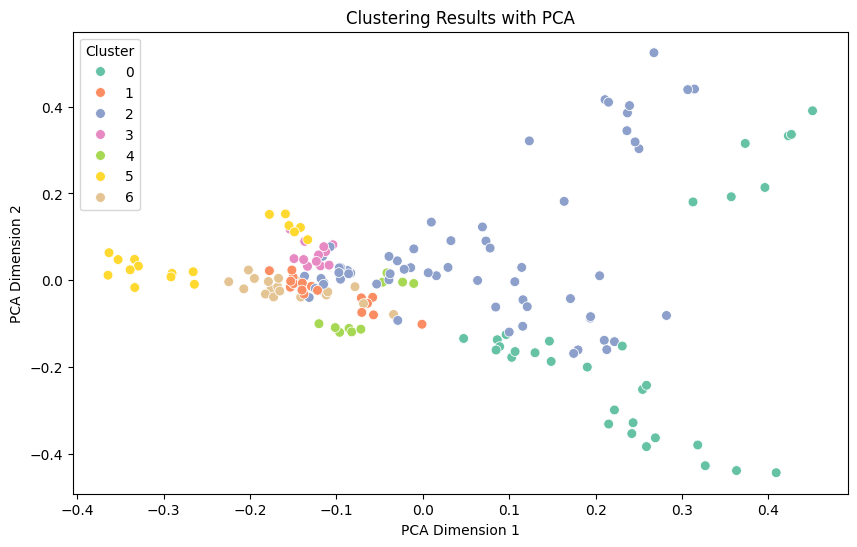

In [103]:
# ลดมิติด้วย PCA ให้เหลือ 2 มิติ
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())  # ใช้ .toarray() เพราะ X เป็น sparse matrix

# เพิ่มข้อมูล PCA ลงใน DataFrame เพื่อทำการพล็อต
df3["pca1"] = X_pca[:, 0]
df3["pca2"] = X_pca[:, 1]

# พล็อตกราฟ
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue=df3['cluster'],
    palette='Set2',  # หรือใช้ palette ที่ต้องการ
    s=50,
    data=df3
)
plt.title("Clustering Results with PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend(title="Cluster")
plt.show()


# Use Stemming

In [104]:
# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=2)
X = vectorizer.fit_transform(df3["stemming"])

In [105]:
min_cluster = 7
max_cluster = 40

In [106]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, cohen_kappa_score

# Function to match clusters to ground truth labels
def match_clusters(y_true, y_pred):
    labels = np.unique(y_true)  # Unique ground truth labels
    clusters = np.unique(y_pred)  # Unique cluster labels

    cost_matrix = np.zeros((len(labels), len(clusters)))  # Cost matrix

    # Fill cost matrix with frequency of (y_true, y_pred) pairs
    for i, label in enumerate(labels):
        for j, cluster in enumerate(clusters):
            cost_matrix[i, j] = np.sum((y_true == label) & (y_pred == cluster))

    # Find optimal mapping
    row_ind, col_ind = linear_sum_assignment(cost_matrix, maximize=True)

    # Map clusters to best matching labels
    cluster_mapping = {clusters[j]: labels[i] for i, j in zip(row_ind, col_ind)}

    # Apply mapping
    y_pred_mapped = np.array([cluster_mapping[c] for c in y_pred])

    return y_pred_mapped

# Lists to store results
num_clusters_list = []
topics_in_multiple_groups_list = []
silhouette_scores = []
kappa_scores = []

for num_clusters in range(min_cluster, max_cluster + 1):
    # Apply clustering
    kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=0, batch_size=100)
    df3["cluster"] = kmeans.fit_predict(X)

    # Calculate Silhouette Score
    silhouette_avg = silhouette_score(X, df3["cluster"])
    silhouette_scores.append(silhouette_avg)

    # Calculate Cohen's Kappa Score with proper cluster matching
    if "topic_encoded" in df3.columns:
        y_true = df3["topic_encoded"].to_numpy()
        y_pred = df3["cluster"].to_numpy()

        # Adjust clusters to match ground truth labels
        y_pred_mapped = match_clusters(y_true, y_pred)

        # Compute Kappa Score
        kappa = cohen_kappa_score(y_true, y_pred_mapped)
    else:
        kappa = None  # Avoid error if no true labels
    kappa_scores.append(kappa)

    # Store number of topics appearing in multiple clusters
    topics_in_multiple_groups = get_cluster_info(num_clusters, num_clusters, df3, X)[1][0]
    num_clusters_list.append(num_clusters)
    topics_in_multiple_groups_list.append(topics_in_multiple_groups)

# Create DataFrame to display the results
cluster_info_df = pd.DataFrame({
    'num_clusters': num_clusters_list,
    'disease_in_multiple_groups': topics_in_multiple_groups_list,
    'silhouette_avg': silhouette_scores,
    'kappa_score': kappa_scores
})

# Display the DataFrame
print(cluster_info_df)


    num_clusters  disease_in_multiple_groups  silhouette_avg kappa_score
0              7                           0        0.048911        None
1              8                           1        0.062634        None
2              9                           2        0.068856        None
3             10                           4        0.073105        None
4             11                           5        0.080712        None
5             12                           3        0.085990        None
6             13                           4        0.096519        None
7             14                           2        0.101792        None
8             15                           4        0.105113        None
9             16                           3        0.110413        None
10            17                           1        0.126895        None
11            18                           2        0.121184        None
12            19                           3       

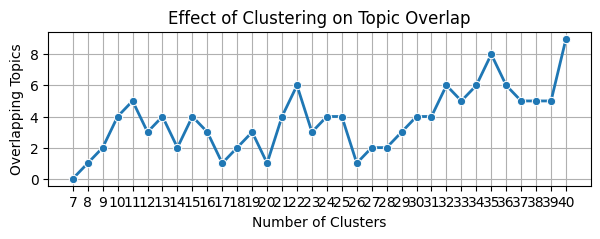

In [107]:
# Plot
plt.figure(figsize=(7, 2))
sns.lineplot(data=cluster_info_df, x="num_clusters", y="disease_in_multiple_groups", marker="o", linewidth=2)

# Labels & Title
plt.xlabel("Number of Clusters")
plt.ylabel("Overlapping Topics")
plt.title("Effect of Clustering on Topic Overlap")
plt.xticks(cluster_info_df["num_clusters"])  # Ensure all x values are displayed
plt.grid(True)

plt.show()

In [108]:
num_clusters = 7  # >>>> change here

# Use MiniBatchKMeans for faster execution
kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=0, batch_size=100)
df3["cluster"] = kmeans.fit_predict(X)

In [109]:
# Find unique mapping between 'cluster' and 'topic'
mapping = df3.groupby('cluster')['topic'].unique().reset_index()

# Display the result as a DataFrame
mapping

,cluster,topic
0,0,"[Binge eating disorder, Dementia, Obsessive-co..."
1,1,"[Common cold, Fungal infections, Pelvic inflam..."
2,2,"[Alzheimer's disease, Bipolar disorder, Depres..."
3,3,"[Acne, Endometriosis, Menstrual disorders, Ost..."
4,4,"[Anxiety, Anxiety disorders, Asthma, Eczema, G..."
5,5,"[Infectious arthritis, Osteoarthritis, Ovarian..."
6,6,"[Fractures, Herniated disk, Periodontal diseas..."


This is a manual comparison of the clustering results with the labeled data (ground truth).
*   cluster 0 = `Mental Health`
*   cluster 1 =  Mixed
*   cluster 2 = Mixed
*   cluster 3 = `Gynecology`
*   cluster 4 = Mixed
*   cluster 5 = Mixed
*   cluster 6 = `Dental Clinic` + Mixed

In [110]:
output_path = "/content/drive/MyDrive/GNG5125_Term Project/result_kmean_tfidf_stemming.csv"
mapping.to_csv(output_path, index=False)

In [111]:
duplicate_topics = df3.groupby('topic')['cluster'].nunique()
topics_in_multiple_groups = duplicate_topics[duplicate_topics > 1]

print(topics_in_multiple_groups)

Series([], Name: cluster, dtype: int64)


In [112]:
df3.head()

,topic,cleaned_text,lemmatization,stemming,cluster,pca1,pca2
0,Acne,acne definition acne common skin condition cha...,acne definition acne common skin condition cha...,acn definit acn common skin condit character p...,3,-0.175554,-0.020828
1,Acne,oral key terms androgens male sex hormones lin...,oral key term androgen male sex hormone linked...,oral key term androgen male sex hormon link de...,3,-0.182141,-0.031743
2,Acne,dead skin cells help unclog pores kill bacteri...,dead skin cell help unclog pore kill bacteria ...,dead skin cell help unclog pore kill bacteria ...,3,-0.172659,-0.038327
3,Acne,attention paid topregnancy tests contraceptive...,attention paid topregnancy test contraceptive ...,attent paid topregn test contracept requir wom...,3,-0.141339,-0.038630
5,Alzheimer's disease,alzheimer disease definition alzheimer disease...,alzheimer disease definition alzheimer disease...,alzheim diseas definit alzheim diseas ad commo...,2,0.210878,0.415971


In [113]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate separate word clouds for each cluster
def plot_wordcloud_by_cluster(df, text_column="stemming", cluster_column="cluster"):
    unique_clusters = df[cluster_column].unique()

    for cluster_num in unique_clusters:
        cluster_text = " ".join(df[df[cluster_column] == cluster_num][text_column])
        wordcloud = WordCloud(width=800, height=400, background_color="white").generate(cluster_text)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Cluster {cluster_num}")
        plt.show()

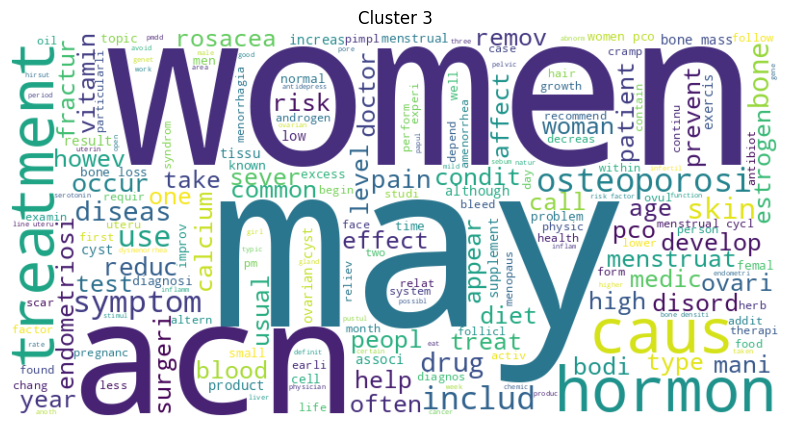

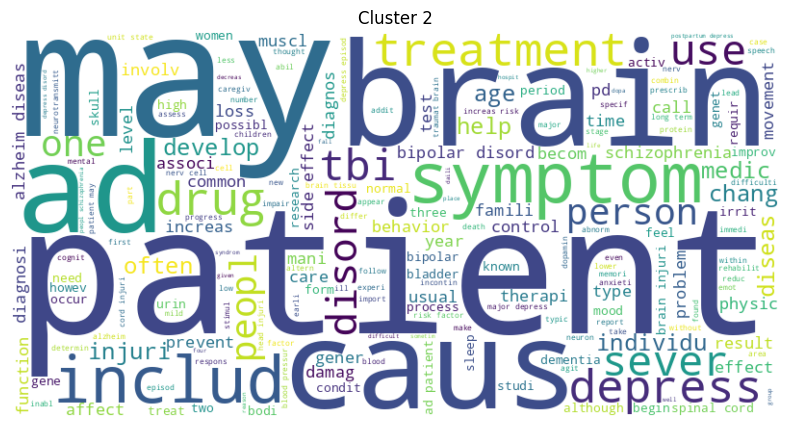

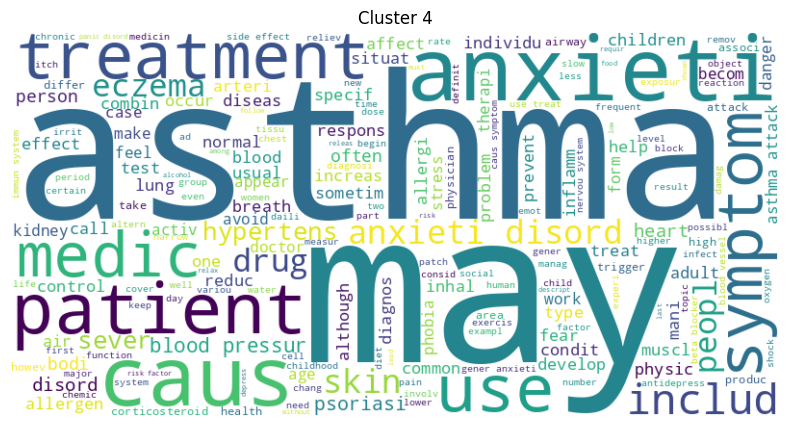

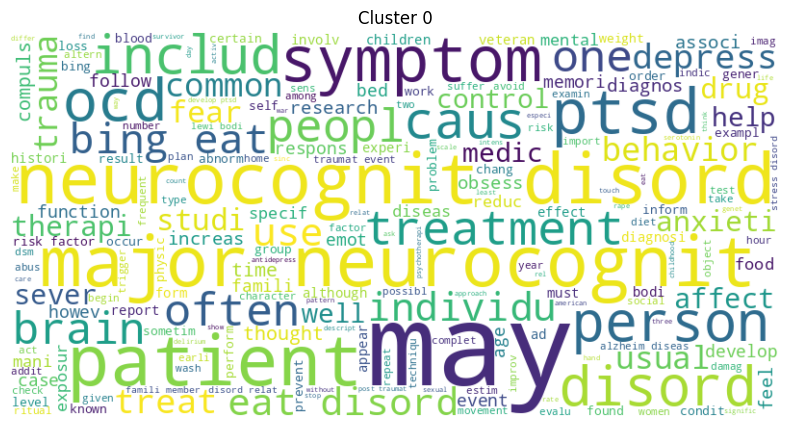

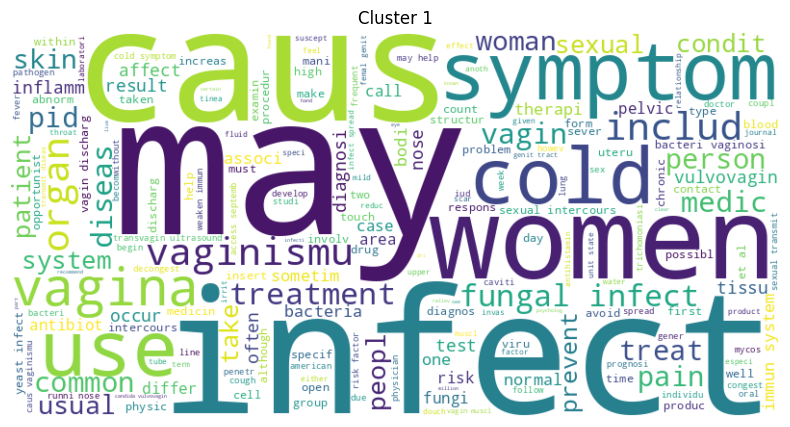

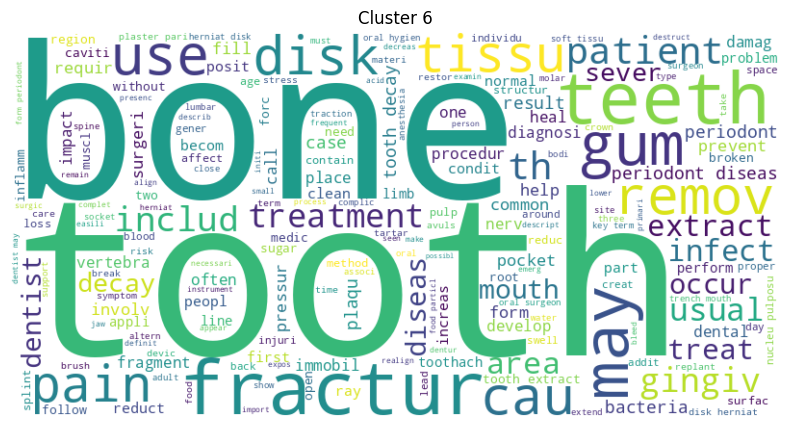

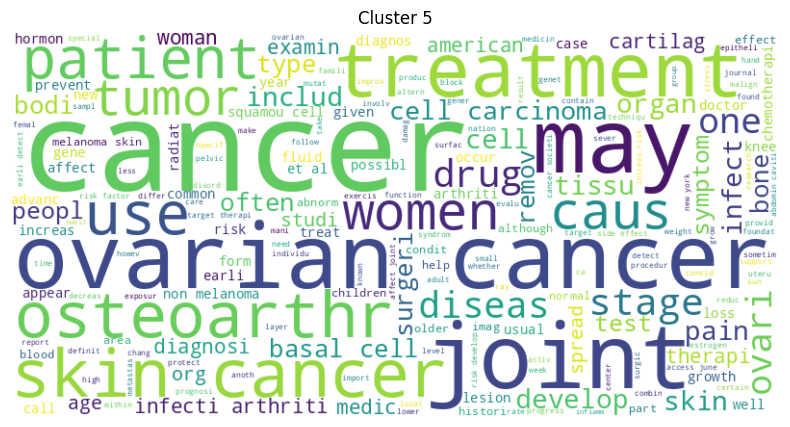

In [114]:
# Example usage:
plot_wordcloud_by_cluster(df3, text_column="stemming", cluster_column="cluster")

Even though all seven clusters are 100% non-overlapping, the diseases and departments still do not match the label data exactly.

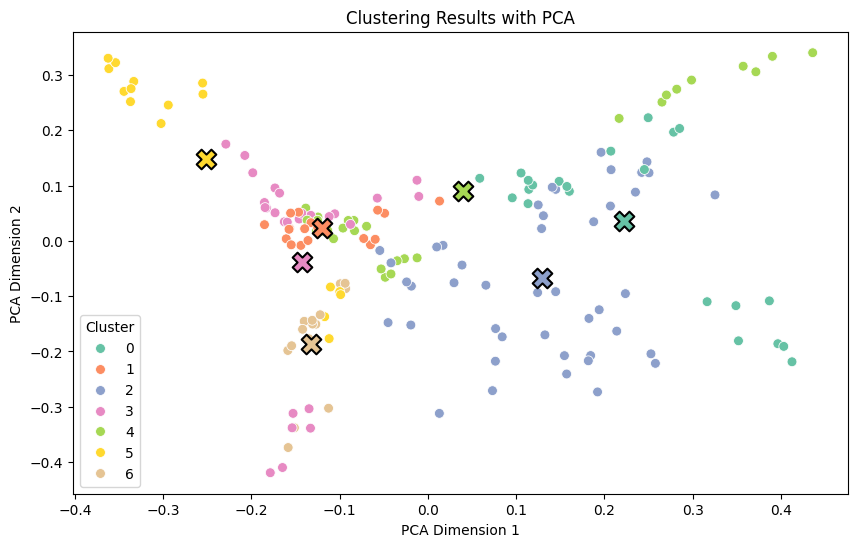

In [115]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

df3["pca1"] = X_pca[:, 0]
df3["pca2"] = X_pca[:, 1]

# Get cluster centers and transform them using PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Define the color palette
palette = sns.color_palette("Set2", n_colors=len(df3["cluster"].unique()))

# Create a mapping from cluster to color
cluster_colors = {cluster: palette[i] for i, cluster in enumerate(sorted(df3["cluster"].unique()))}

# Plot the clustered data points
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue=df3['cluster'],
    palette=palette,
    s=50,
    data=df3
)

# Plot the cluster centroids with matching colors
for i, centroid in enumerate(centroids_pca):
    plt.scatter(
        centroid[0], centroid[1],
        color=palette[i],  # Match cluster color
        marker='X',
        s=200,
        edgecolors='black',
        linewidth=1.5
    )

plt.title("Clustering Results with PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend(title="Cluster")
plt.show()

# Try K=30

In [128]:
# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=2)
X = vectorizer.fit_transform(df3["stemming"])

In [129]:
num_clusters = 30  # >>>> change here

# Use MiniBatchKMeans for faster execution
kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=0, batch_size=100)
df3["cluster"] = kmeans.fit_predict(X)

In [130]:
# Find unique mapping between 'cluster' and 'topic'
mapping = df3.groupby('cluster')['topic'].unique().reset_index()

# Display the result as a DataFrame
mapping

,cluster,topic
0,0,[Obsessive-compulsive disorder]
1,1,[Pelvic inflammatory disease]
2,2,"[Bipolar disorder, Depressive disorders, Postp..."
3,3,"[Ovarian cancer, Skin cancer, non-melanoma]"
4,4,[Fractures]
5,5,[Traumatic brain injury]
6,6,"[Herniated disk, Tooth decay, Tooth extraction..."
7,7,[Asthma]
8,8,[Alzheimer's disease]
9,9,"[Acne, Rosacea]"


In [131]:
duplicate_topics = df3.groupby('topic')['cluster'].nunique()
topics_in_multiple_groups = duplicate_topics[duplicate_topics > 1]

print(topics_in_multiple_groups)

topic
Bipolar disorder             2
Herniated disk               2
Skin cancer, non-melanoma    2
Spinal cord injury           2
Name: cluster, dtype: int64


#### find Top 10 mismatch word

In [133]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# Filter rows where topic is in multiple groups
filtered_df = df3[df3['topic'].isin(topics_in_multiple_groups.index)]

# Tokenize the 'stemming' column to extract single words and 2-grams
vectorizer = CountVectorizer(ngram_range=(1, 1))  # For single words
X = vectorizer.fit_transform(filtered_df['stemming'])
words = vectorizer.get_feature_names_out()
word_counts = X.sum(axis=0).A1  # Sum word occurrences
word_freq = dict(zip(words, word_counts))

# Get top 10 frequent words
top_words = Counter(word_freq).most_common(10)
top_words

[('skin', np.int64(104)),
 ('cancer', np.int64(98)),
 ('may', np.int64(88)),
 ('bipolar', np.int64(86)),
 ('cell', np.int64(81)),
 ('disord', np.int64(77)),
 ('disk', np.int64(67)),
 ('use', np.int64(63)),
 ('patient', np.int64(55)),
 ('depress', np.int64(54))]

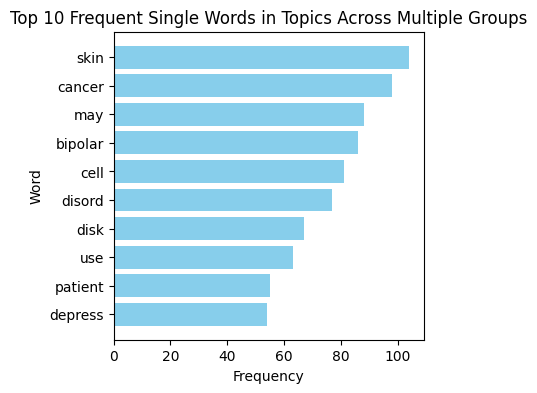

In [139]:
# Sort top words in descending order by frequency
top_words_sorted = sorted(top_words, key=lambda x: x[1], reverse=False)

# Plot top 10 frequent words (Single Words) - Horizontal Bar Chart
plt.figure(figsize=(4, 4))
plt.barh([x[0] for x in top_words_sorted], [x[1] for x in top_words_sorted], color='skyblue')
plt.title('Top 10 Frequent Single Words in Topics Across Multiple Groups')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [142]:
# Now for 2-grams (ngram_range=(2, 2))
vectorizer_2gram = CountVectorizer(ngram_range=(2, 2))  # For 2-grams
X_2gram = vectorizer_2gram.fit_transform(filtered_df['stemming'])
two_grams = vectorizer_2gram.get_feature_names_out()
two_gram_counts = X_2gram.sum(axis=0).A1
two_gram_freq = dict(zip(two_grams, two_gram_counts))

# Get top 10 frequent 2-grams
top_two_grams = Counter(two_gram_freq).most_common(10)

# Sort top 2-grams in ascending order by frequency
top_two_grams_sorted = sorted(top_two_grams, key=lambda x: x[1], reverse=False)



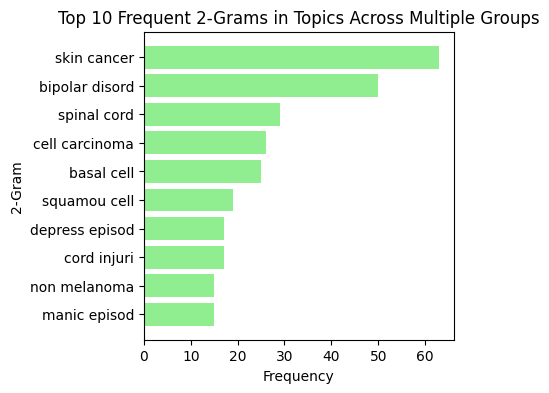

In [143]:
# Plot top 10 frequent 2-grams - Horizontal Bar Chart
plt.figure(figsize=(4, 4))
plt.barh([x[0] for x in top_two_grams_sorted], [x[1] for x in top_two_grams_sorted], color='lightgreen')
plt.title('Top 10 Frequent 2-Grams in Topics Across Multiple Groups')
plt.xlabel('Frequency')
plt.ylabel('2-Gram')
plt.show()

# Dataset2: Symptom2Disease

In [116]:
file_path = '/content/drive/MyDrive/GNG5125_Term Project/Symptom2Disease.csv'
df_symptom = pd.read_csv(file_path)
df_symptom.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [117]:
df_symptom.loc[:, 'cleaned_text'] = df_symptom['text'].apply(clean_data)
df_symptom.head()

,Unnamed: 0,label,text,cleaned_text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...,experiencing skin rash arms legs torso past we...
1,1,Psoriasis,"My skin has been peeling, especially on my kne...",skin peeling especially knees elbows scalp pee...
2,2,Psoriasis,I have been experiencing joint pain in my fing...,experiencing joint pain fingers wrists knees p...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp...",silver like dusting skin especially lower back...
4,4,Psoriasis,"My nails have small dents or pits in them, and...",nails small dents pits often feel inflammatory...


In [118]:
df_symptom.loc[:, 'lemmatization'] = df_symptom['cleaned_text'].apply(apply_lemmatization)
df_symptom['stemming'] = df_symptom['cleaned_text'].apply(apply_stemming)
df_symptom.head()

,Unnamed: 0,label,text,cleaned_text,lemmatization,stemming
0,0,Psoriasis,I have been experiencing a skin rash on my arm...,experiencing skin rash arms legs torso past we...,experiencing skin rash arm leg torso past week...,experienc skin rash arm leg torso past week re...
1,1,Psoriasis,"My skin has been peeling, especially on my kne...",skin peeling especially knees elbows scalp pee...,skin peeling especially knee elbow scalp peeli...,skin peel especi knee elbow scalp peel often a...
2,2,Psoriasis,I have been experiencing joint pain in my fing...,experiencing joint pain fingers wrists knees p...,experiencing joint pain finger wrist knee pain...,experienc joint pain finger wrist knee pain of...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp...",silver like dusting skin especially lower back...,silver like dusting skin especially lower back...,silver like dust skin especi lower back scalp ...
4,4,Psoriasis,"My nails have small dents or pits in them, and...",nails small dents pits often feel inflammatory...,nail small dent pit often feel inflammatory te...,nail small dent pit often feel inflammatori te...


In [119]:
# find the best num_clusters
def get_cluster_info2(min_cluster, max_cluster, df3, X):
    num_clusters_list = []  # list to store num_clusters
    topics_in_multiple_groups_list = []  # list to store length of topics_in_multiple_groups

    # Loop over the range of num_clusters
    for num_clusters in range(min_cluster, max_cluster + 1):
        # Use MiniBatchKMeans for clustering
        kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=0, batch_size=100)
        df3["cluster"] = kmeans.fit_predict(X)

        # Find unique mapping between 'cluster' and 'topic'
        mapping = df3.groupby('cluster')['label'].unique().reset_index()

        # Find the duplicate topics across different clusters
        duplicate_topics = df3.groupby('label')['cluster'].nunique()

        # Filter topics that appear in more than one cluster
        topics_in_multiple_groups = duplicate_topics[duplicate_topics > 1]

        # Append the results to the lists
        num_clusters_list.append(num_clusters)
        topics_in_multiple_groups_list.append(len(topics_in_multiple_groups))

    return num_clusters_list, topics_in_multiple_groups_list

### Use Stemming

In [120]:
# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=2)
X = vectorizer.fit_transform(df_symptom["stemming"])

min_cluster = 3
max_cluster = 10

# Call the function with the parameters
num_clusters_list, topics_in_multiple_groups_list = get_cluster_info2(min_cluster, max_cluster, df_symptom, X)

# Create a DataFrame to display the results
cluster_info_df = pd.DataFrame({
    'num_clusters': num_clusters_list,
    'topics_in_multiple_groups': topics_in_multiple_groups_list
})

# Display the DataFrame
print(cluster_info_df)

   num_clusters  topics_in_multiple_groups
0             3                         12
1             4                         13
2             5                         16
3             6                         16
4             7                         16
5             8                         14
6             9                         14
7            10                         17


In [121]:
df_symptom.head()

,Unnamed: 0,label,text,cleaned_text,lemmatization,stemming,cluster
0,0,Psoriasis,I have been experiencing a skin rash on my arm...,experiencing skin rash arms legs torso past we...,experiencing skin rash arm leg torso past week...,experienc skin rash arm leg torso past week re...,0
1,1,Psoriasis,"My skin has been peeling, especially on my kne...",skin peeling especially knees elbows scalp pee...,skin peeling especially knee elbow scalp peeli...,skin peel especi knee elbow scalp peel often a...,1
2,2,Psoriasis,I have been experiencing joint pain in my fing...,experiencing joint pain fingers wrists knees p...,experiencing joint pain finger wrist knee pain...,experienc joint pain finger wrist knee pain of...,1
3,3,Psoriasis,"There is a silver like dusting on my skin, esp...",silver like dusting skin especially lower back...,silver like dusting skin especially lower back...,silver like dust skin especi lower back scalp ...,1
4,4,Psoriasis,"My nails have small dents or pits in them, and...",nails small dents pits often feel inflammatory...,nail small dent pit often feel inflammatory te...,nail small dent pit often feel inflammatori te...,1


In [122]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, cohen_kappa_score

# Function to match clusters to ground truth labels
def match_clusters(y_true, y_pred):
    labels = np.unique(y_true)  # Unique ground truth labels
    clusters = np.unique(y_pred)  # Unique cluster labels

    cost_matrix = np.zeros((len(labels), len(clusters)))  # Cost matrix

    # Fill cost matrix with frequency of (y_true, y_pred) pairs
    for i, label in enumerate(labels):
        for j, cluster in enumerate(clusters):
            cost_matrix[i, j] = np.sum((y_true == label) & (y_pred == cluster))

    # Find optimal mapping
    row_ind, col_ind = linear_sum_assignment(cost_matrix, maximize=True)

    # Map clusters to best matching labels
    cluster_mapping = {clusters[j]: labels[i] for i, j in zip(row_ind, col_ind)}

    # Apply mapping
    y_pred_mapped = np.array([cluster_mapping[c] for c in y_pred])

    return y_pred_mapped

# Lists to store results
num_clusters_list = []
topics_in_multiple_groups_list = []
silhouette_scores = []
kappa_scores = []

In [123]:
for num_clusters in range(min_cluster, max_cluster + 1):
    # Apply clustering
    kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=0, batch_size=100)
    df_symptom["cluster"] = kmeans.fit_predict(X)

    # Calculate Silhouette Score
    silhouette_avg = silhouette_score(X, df_symptom["cluster"])
    silhouette_scores.append(silhouette_avg)

    # Calculate Cohen's Kappa Score with proper cluster matching
    if "topic_encoded" in df_symptom.columns:
        y_true = df_symptom["topic_encoded"].to_numpy()
        y_pred = df_symptom["cluster"].to_numpy()

        # Adjust clusters to match ground truth labels
        y_pred_mapped = match_clusters(y_true, y_pred)

        # Get the common labels in both y_true and y_pred_mapped
        common_labels = np.intersect1d(y_true, y_pred_mapped)

        # Mask to filter only common labels
        mask = np.isin(y_true, common_labels) & np.isin(y_pred_mapped, common_labels)

        # Compute Kappa Score only for matching labels
        if mask.sum() > 0:  # Ensure there's data to compare
            kappa = cohen_kappa_score(y_true[mask], y_pred_mapped[mask])
        else:
            kappa = None
    else:
        kappa = None  # Avoid error if no true labels

    kappa_scores.append(kappa)

    # Store number of topics appearing in multiple clusters
    topics_in_multiple_groups = get_cluster_info2(num_clusters, num_clusters, df_symptom, X)[1][0]
    num_clusters_list.append(num_clusters)
    topics_in_multiple_groups_list.append(topics_in_multiple_groups)

In [124]:
# Create DataFrame to display the results
cluster_info_df = pd.DataFrame({
    'num_clusters': num_clusters_list,
    'disease_in_multiple_groups': topics_in_multiple_groups_list,
    'silhouette_avg': silhouette_scores,
    'kappa_score': kappa_scores
})

# Display the DataFrame
print(cluster_info_df)

   num_clusters  disease_in_multiple_groups  silhouette_avg kappa_score
0             3                          12        0.025840        None
1             4                          13        0.026885        None
2             5                          16        0.028014        None
3             6                          16        0.028909        None
4             7                          16        0.034943        None
5             8                          14        0.037730        None
6             9                          14        0.042581        None
7            10                          17        0.046888        None


It's possible that Cohen's Kappa Score cannot be calculated due to an insufficient number of samples or a lack of overlap between y_true and y_pred_mapped.

In [125]:
print("Unique y_true:", np.unique(y_true))
print("Unique y_pred:", np.unique(y_pred))
print("Unique y_pred_mapped:", np.unique(y_pred_mapped))


Unique y_true: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Unique y_pred: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Unique y_pred_mapped: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 24
 25 26 27 28 29 30 31 34 36 37 38 39 43 44 46 47]


The reason why cannot calculate Kappa Score
*   `y_true` has labels from 0 to 47, which indicates that there are 48 unique classes in the ground truth.
*   `y_pred` has labels from 0 to 39, which indicates that there are 40 unique clusters, suggesting that some ground truth labels may not be present in the clustering results.
*   y_pred_mapped has 40 unique values, but not all of the ground truth labels from y_true are accounted for. Some labels from y_true are missing from y_pred_mapped (e.g., 23, 33, 42).










In [126]:
print("y_pred_mapped unique values:", np.unique(y_pred_mapped, return_counts=True))

y_pred_mapped unique values: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 34, 36, 37,
       38, 39, 43, 44, 46, 47]), array([ 6, 21,  9,  1,  6,  4,  8,  1,  6,  2,  4,  3,  4,  5,  1,  3,  2,
        4,  3,  6,  1,  6,  8,  2,  3,  3,  5,  5,  2,  4,  3,  4,  3,  1,
        3,  3,  7,  2,  3,  3]))
